#Realizando importações

In [62]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import json
import ssl
import urllib.parse
import urllib.request
import certifi
import matplotlib.pyplot as plt
import requests
import seaborn as sns
import time

#Função de busca

In [63]:
def search_crypto(coin_id, colunm_name):
    url = f"https://api.coingecko.com/api/v3/coins/{coin_id}/market_chart"
    params = {
        "vs_currency": "usd",
        "days": "365",
        "interval": "daily"
    }
    response = requests.get(url, params=params)
    data = response.json()
    df = pd.DataFrame(data["prices"], columns=["timeOpen", colunm_name])
    df["timeOpen"] = pd.to_datetime(df["timeOpen"], unit="ms")
    return df

# Criando o Dataset

In [64]:
# Busca os dados
btc = search_crypto("bitcoin", "BTC")
eth = search_crypto("ethereum", "ETH")
xrp = search_crypto("ripple", "XRP")
tet = search_crypto("tether", "TET")
sol = search_crypto("solana", "SOL")

# Unificando os dados
df = btc.merge(eth, on="timeOpen")
df = df.merge(xrp, on="timeOpen")
df = df.merge(tet, on="timeOpen")
df = df.merge(sol, on="timeOpen")

# 5 primeiros dados
print(df.head())

# Tipo de colunas retornadas
print("\nTipos das colunas:")
print(df.dtypes)

    timeOpen            BTC          ETH       XRP       TET         SOL
0 2025-05-13  102876.830429  2492.426391  2.540717  1.000036  174.419502
1 2025-05-14  104184.490393  2676.639163  2.588266  1.000132  184.053798
2 2025-05-15  103594.425751  2603.718089  2.552660  1.000164  176.455072
3 2025-05-16  103708.851364  2542.296692  2.378020  1.000134  168.752697
4 2025-05-17  103556.034940  2544.387038  2.387491  1.000215  167.768124

Tipos das colunas:
timeOpen    datetime64[ns]
BTC                float64
ETH                float64
XRP                float64
TET                float64
SOL                float64
dtype: object


#Gráfico da Série Temporal

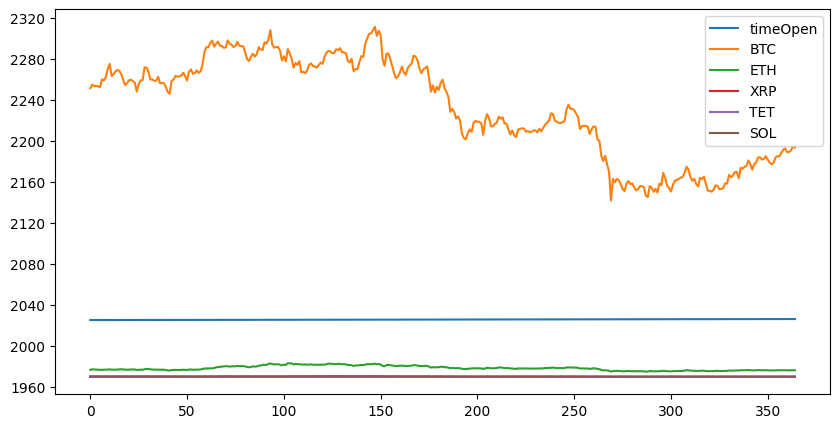

In [65]:
plt.rcParams['figure.figsize'] = [10, 5]
df.plot()
plt.show()

In [66]:
# Retirando a coluna timeOpen
df = df.drop(columns=['timeOpen'])

# Correlação entre os dados

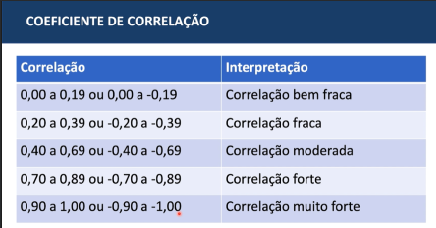

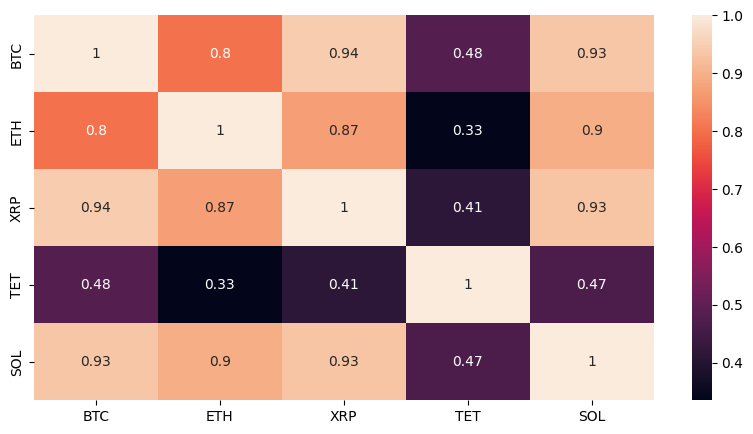

In [67]:
sns.heatmap(df.corr(), annot=True);

## Análise da Correlação

A Cryptomoeda XRP apresenta maior correlação que as demais

<Axes: xlabel='XRP', ylabel='BTC'>

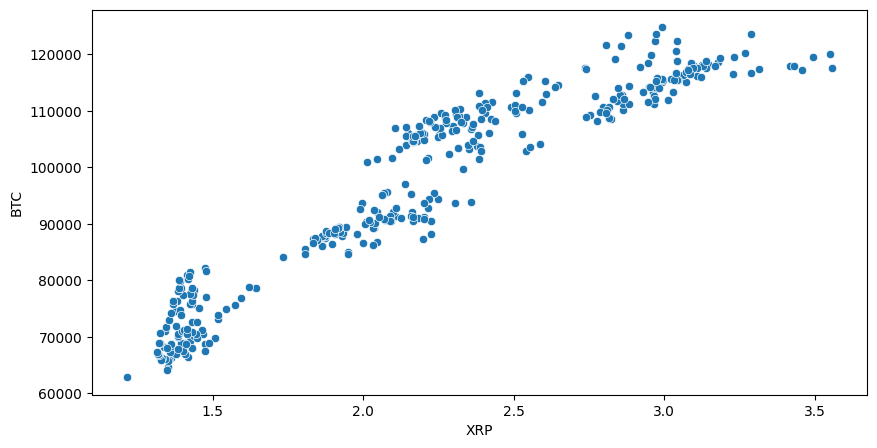

In [68]:
# Correlação muito forte
sns.scatterplot(x=df['XRP'], y=df['BTC'])


<Axes: xlabel='TET', ylabel='BTC'>

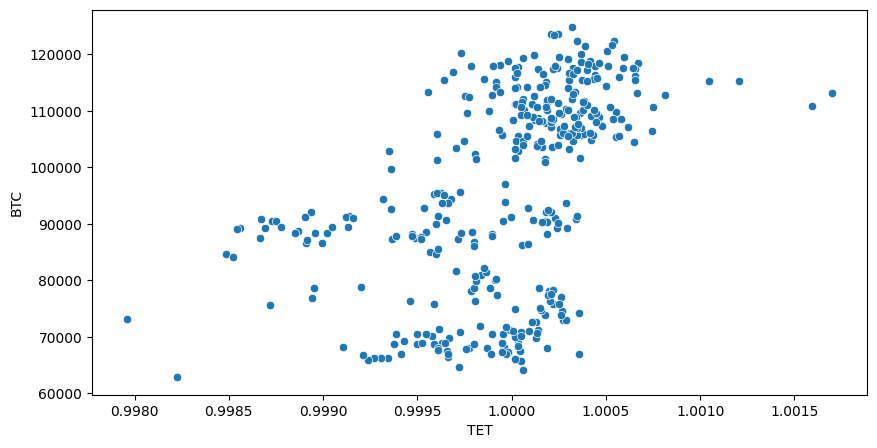

In [69]:
# Correlação moderada
sns.scatterplot(x=df['TET'], y=df['BTC'])


#Treinamento

In [70]:
# Retirando a moeda com a Coeficiente de Determinação Inferior a 0,7
df = df.drop(columns=['TET'])

In [71]:
import math
print(math.pow(0.94, 2))

# Definindo as varíaveis x e y
x = df[["ETH", "XRP", "SOL"]]
y = df["BTC"]

# Treinamento e teste 20%
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=1) # random_state=1 (mesma divisão da base de dados) / shuffle=False

# Tamanho dos dados
X_train.shape, X_test.shape



0.8835999999999999


((292, 3), (73, 3))

#Modelo Escolhido

In [72]:
from sklearn.linear_model import LinearRegression

# Modelo
regressor = LinearRegression()

# Treinar
regressor.fit(X_train, y_train)

LinearRegression()

#Previsão

In [73]:
y_pred = regressor.predict(X_test)
print(y_pred[:10])

[ 71401.06360925  97462.78627621 110830.05890546  99911.43267697
  73741.73715336  71024.92396851  84812.41678986  90221.76639943
  72550.08990722 108412.9432516 ]


#Avaliar modelo

Coefficients: 
 [-6.84667378e+00  1.75477984e+04  2.58356720e+02]
Mean squared error: 22746798.80
Coefficient of determination: 0.93
Score de Treinamento: 0.9297
Score de Teste: 0.9311
Nível de acerto R²: 0.9311
Erro médio absoluto: 4067.47


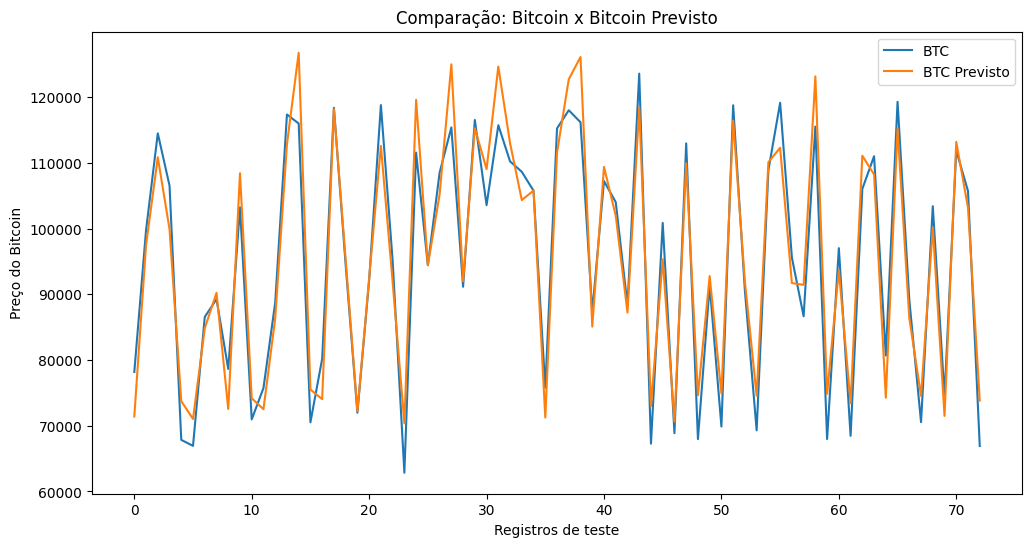

In [74]:
from sklearn.metrics import mean_squared_error, r2_score

# The coefficients
print('Coefficients: \n', regressor.coef_)

# The mean squared error
print('Mean squared error: %.2f' % mean_squared_error(y_test, y_pred))

# The coefficient of determination: 1 is perfect prediction
print('Coefficient of determination: %.2f' % r2_score(y_test, y_pred))

# Score treinamento
print(f"Score de Treinamento: {regressor.score(X_train, y_train):.4f}")

# Score teste
print(f"Score de Teste: {regressor.score(X_test, y_test):.4f}")

# Avaliar o modelo
min_len = min(len(y_test), len(y_pred))

r2 = r2_score(y_test[:min_len], y_pred[:min_len])
mae = mean_absolute_error(y_test[:min_len], y_pred[:min_len])

print(f"Nível de acerto R²: {r2:.4f}")
print(f"Erro médio absoluto: {mae:.2f}")

# Gráfico
plt.figure(figsize=(12, 6))
plt.plot(y_test.values[:min_len], label="BTC")
plt.plot(y_pred[:min_len], label="BTC Previsto")

plt.title("Comparação: Bitcoin x Bitcoin Previsto")
plt.xlabel("Registros de teste")
plt.ylabel("Preço do Bitcoin")
plt.legend()
plt.show()

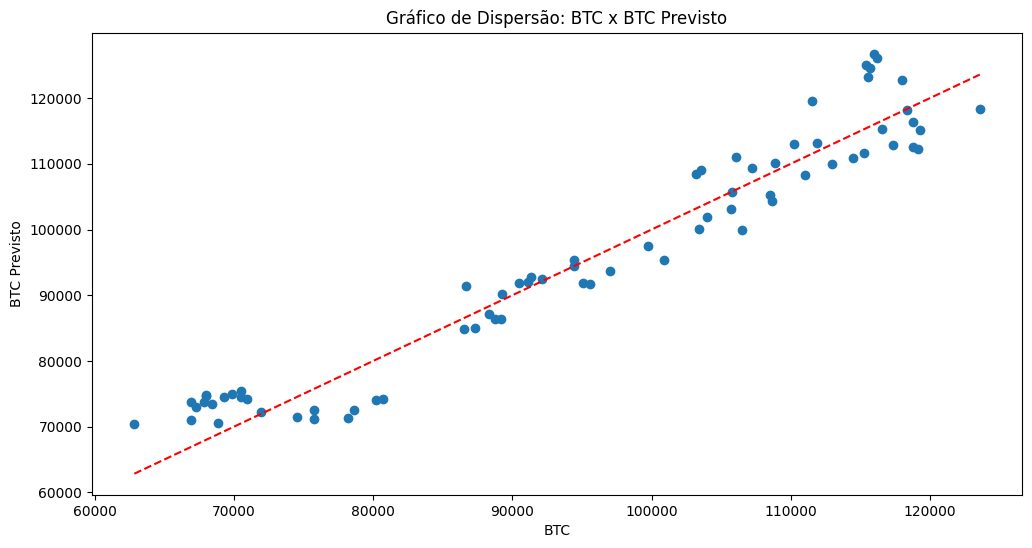

In [75]:
# Gráfico
plt.figure(figsize=(12, 6))
# Plot an ideal prediction line (y=x)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.scatter(y_test, y_pred)

plt.xlabel("BTC")
plt.ylabel("BTC Previsto")
plt.title("Gráfico de Dispersão: BTC x BTC Previsto")
plt.show()

Avaliando com 30% de treinamento

[113998.80640649  87095.57377504  96826.00063605 100075.20616413
 116948.15365204  73369.0334437  115799.15329994  75185.85516259
  96018.24834133 109589.42139665]
Coefficients: 
 [-5.42480201e+00  1.72908370e+04  2.34513076e+02]
Mean squared error: 18624207.77
Coefficient of determination: 0.94
Score de Treinamento: 0.9239792879302956
Score de Teste: 0.943317055082062
Nível de acerto R²: 0.9433
Erro médio absoluto: 3570.68


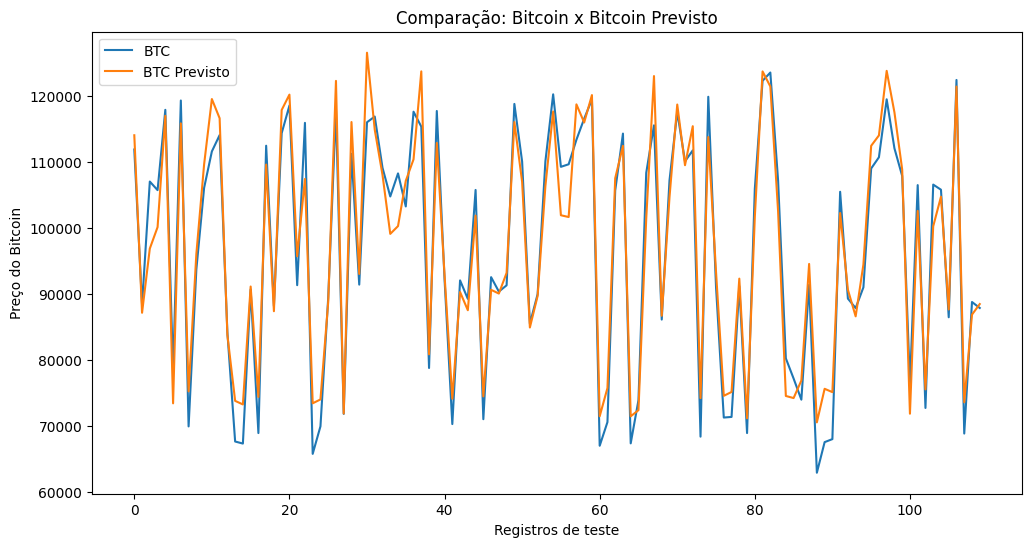

In [76]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Definindo o Conjunto de Treinamento e de Validação (30%)
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=0)

# Tamanho dos dados
X_train.shape, X_test.shape

# Modelo
regressor = LinearRegression()

# Treinar
regressor.fit(X_train, y_train)

# Previsão
y_pred = regressor.predict(X_test)
print(y_pred[:10])

# The coefficients
print('Coefficients: \n', regressor.coef_)

# The mean squared error
print('Mean squared error: %.2f' % mean_squared_error(y_test, y_pred))

# The coefficient of determination: 1 is perfect prediction
print('Coefficient of determination: %.2f' % r2_score(y_test, y_pred))

# Score treinamento
print(f"Score de Treinamento: {regressor.score(X_train, y_train)}")

# Score teste
print(f"Score de Teste: {regressor.score(X_test, y_test)}")

# Avaliar o modelo
min_len = min(len(y_test), len(y_pred))

r2 = r2_score(y_test[:min_len], y_pred[:min_len])
mae = mean_absolute_error(y_test[:min_len], y_pred[:min_len])

print(f"Nível de acerto R²: {r2:.4f}")
print(f"Erro médio absoluto: {mae:.2f}")

# Gráfico
plt.figure(figsize=(12, 6))
plt.plot(y_test.values[:min_len], label="BTC")
plt.plot(y_pred[:min_len], label="BTC Previsto")

plt.title("Comparação: Bitcoin x Bitcoin Previsto")
plt.xlabel("Registros de teste")
plt.ylabel("Preço do Bitcoin")
plt.legend()
plt.show()


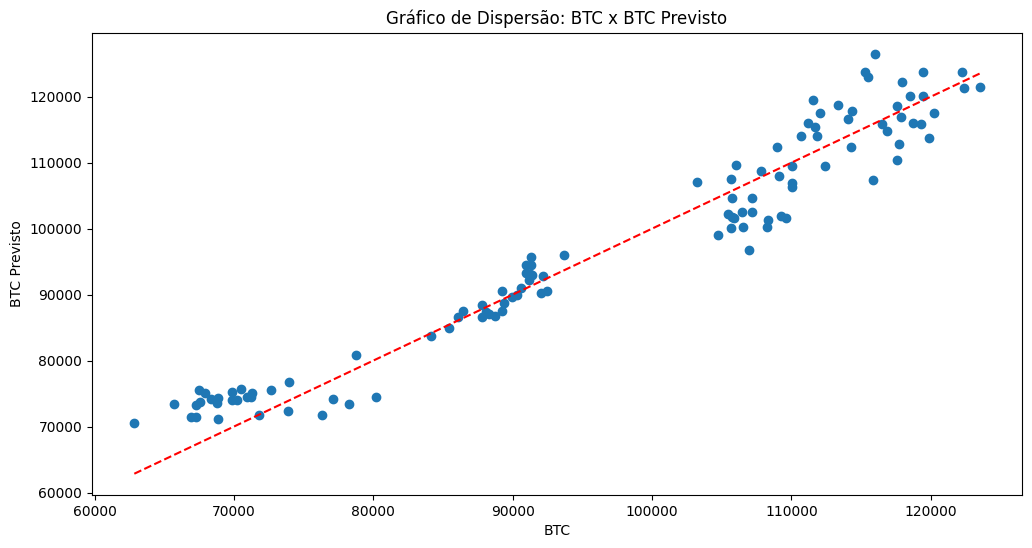

In [77]:
# Gráfico
plt.figure(figsize=(12, 6))
# Plot an ideal prediction line (y=x)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.scatter(y_test, y_pred)

plt.xlabel("BTC")
plt.ylabel("BTC Previsto")
plt.title("Gráfico de Dispersão: BTC x BTC Previsto")
plt.show()